# Country-Level CO₂ Emissions Forecasting
## CRISP-DM Time-Series Machine Learning Project

**Dataset:** Our World in Data CO₂ dataset  
**Target:** `co2`  
**Unit of analysis:** Country-year  
**Country identifier:** `iso_code`  
**Historical period:** 1950 onward

### Project purpose
This notebook develops a country-level time-series forecasting pipeline for annual CO₂ emissions. It follows the **CRISP-DM** methodology and deliberately separates past information from future information to avoid data leakage.

The project asks:

1. **How accurately can historical CO₂ emissions be used to predict future CO₂ emissions for individual countries?**
2. **Which economic, population and energy-related factors are most useful for predicting future CO₂ emissions?**
3. **How do CO₂ emission trends differ across countries over time?**
4. **Can a single forecasting model accurately predict CO₂ emissions across countries using ISO codes and historical characteristics?**
5. **Which time-series modelling approach provides the most accurate CO₂ forecasts?**
6. **How far into the future can CO₂ emissions be forecast with acceptable prediction accuracy?**
7. **Which countries are expected to experience increasing or decreasing CO₂ emissions based on historical trends?**

## 1. CRISP-DM — Business Understanding

### Why is this project important?

CO₂ emissions are closely connected to energy use, economic activity and population. The **IPCC Sixth Assessment Report** identifies population growth and GDP per capita as important drivers of fossil-fuel CO₂ emissions, while energy intensity and the carbon intensity of energy also affect emissions.

Previous research also demonstrates the value of machine learning for country-level emissions forecasting. **Costantini et al. (2024), Scientific Reports**, developed CO₂ forecasting models for **117 countries** using socioeconomic, energy and economic-complexity indicators and compared modelling approaches including Random Forest.

This project applies the same general forecasting idea to the OWID dataset, while adding explicit time-series features such as lagged emissions and rolling averages.

### Business objective

The aim is to develop an accurate and interpretable model that can forecast future national CO₂ emissions and help identify countries with increasing or decreasing emissions trajectories.

### Success criteria

A successful model should:
- outperform a simple persistence baseline;
- avoid temporal data leakage;
- provide low MAE and RMSE;
- perform reasonably across individual countries;
- identify useful predictors;
- generate future country-level forecasts.

**Research sources:**  
- IPCC AR6 WGIII, Chapter 2: https://www.ipcc.ch/report/ar6/wg3/downloads/report/IPCC_AR6_WGIII_Chapter02.pdf
- Costantini et al. (2024), *Scientific Reports*: https://www.nature.com/articles/s41598-024-73060-0

## 2. CRISP-DM — Data Understanding

We first inspect the structure, time period, countries, ISO codes, data types and missing values.

### Why do this?

Before modelling, we need to understand whether the dataset contains duplicate country-year observations, missing identifiers, variables with excessive missingness, and variables that could cause target leakage.

The OWID dataset contains many variables, but **not all should be used as predictors**. Some are components of total CO₂, some are mathematical transformations of CO₂, and some contain global shares or cumulative measures.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

file_path = "owid-co2-data.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (50411, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

None

In [3]:
# Basic dataset summary
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])
print("Year range:", df["year"].min(), "to", df["year"].max())
print("Countries:", df["country"].nunique())
print("Unique ISO codes:", df["iso_code"].nunique())

display(df[["country", "iso_code", "year"]].head(10))

Number of rows: 50411
Number of columns: 79
Year range: 1750 to 2024
Countries: 254
Unique ISO codes: 218


,country,iso_code,year
0,Afghanistan,AFG,1750
1,Afghanistan,AFG,1751
2,Afghanistan,AFG,1752
3,Afghanistan,AFG,1753
4,Afghanistan,AFG,1754
5,Afghanistan,AFG,1755
6,Afghanistan,AFG,1756
7,Afghanistan,AFG,1757
8,Afghanistan,AFG,1758
9,Afghanistan,AFG,1759


## 3. Check Country and ISO-Code Quality

### Why do this?

`iso_code` provides a consistent identifier for countries. It is especially useful for creating time-series features because the same country's observations can be grouped together without relying only on country-name strings.

Rows without ISO codes will be excluded from the country-level forecasting dataset.

In [4]:
# Missing ISO codes
print("Missing ISO codes:", df["iso_code"].isna().sum())

# Countries represented by missing ISO codes
display(
    df.loc[df["iso_code"].isna(), "country"]
      .value_counts()
      .head(20)
)

Missing ISO codes: 7931


country
Africa                           275
Asia                             275
Asia (excl. China and India)     275
Europe                           275
Europe (excl. EU-27)             275
Europe (excl. EU-28)             275
European Union (27)              275
European Union (28)              275
High-income countries            275
International aviation           275
International shipping           275
Low-income countries             275
Lower-middle-income countries    275
North America                    275
North America (excl. USA)        275
Oceania                          275
South America                    275
Upper-middle-income countries    275
World                            275
Africa (GCP)                     175
Name: count, dtype: int64

## 4. Restrict the Historical Period

### Why remove years before 1950?

The project focuses on the modern period in which economic activity, energy systems and emissions data are more relevant to contemporary forecasting. Earlier historical observations also contain substantially more gaps and can make comparisons across countries less consistent.

Therefore, this project uses **1950 onward**.

In [5]:
df = df[df["year"] >= 1950].copy()

print("New year range:", df["year"].min(), "to", df["year"].max())
print("Rows after year filtering:", len(df))

New year range: 1950 to 2024
Rows after year filtering: 18984


## 5. Remove Rows Without Country Identifiers

### Why?

The forecasting unit is **one country in one year**. Without an ISO code, an observation cannot reliably be assigned to a country-specific time series.

In [6]:
df = df[df["iso_code"].notna()].copy()

print("Rows after removing missing ISO codes:", len(df))
print("Countries remaining:", df["iso_code"].nunique())

Rows after removing missing ISO codes: 16350
Countries remaining: 218


## 6. Check for Duplicate Country-Year Records

### Why?

A country-year should normally represent one annual observation. Duplicate `iso_code + year` combinations could distort lag creation and model training.

In [7]:
duplicates = df.duplicated(subset=["iso_code", "year"]).sum()
print("Duplicate country-year records:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates(subset=["iso_code", "year"], keep="first")

print("Shape after duplicate handling:", df.shape)

Duplicate country-year records: 0
Shape after duplicate handling: (16350, 79)


## 7. Explore CO₂ Trends

### Why?

Visualising the target before modelling helps identify long-term trends, abrupt changes and differences between countries. It also helps us understand why a time-aware validation strategy is necessary.

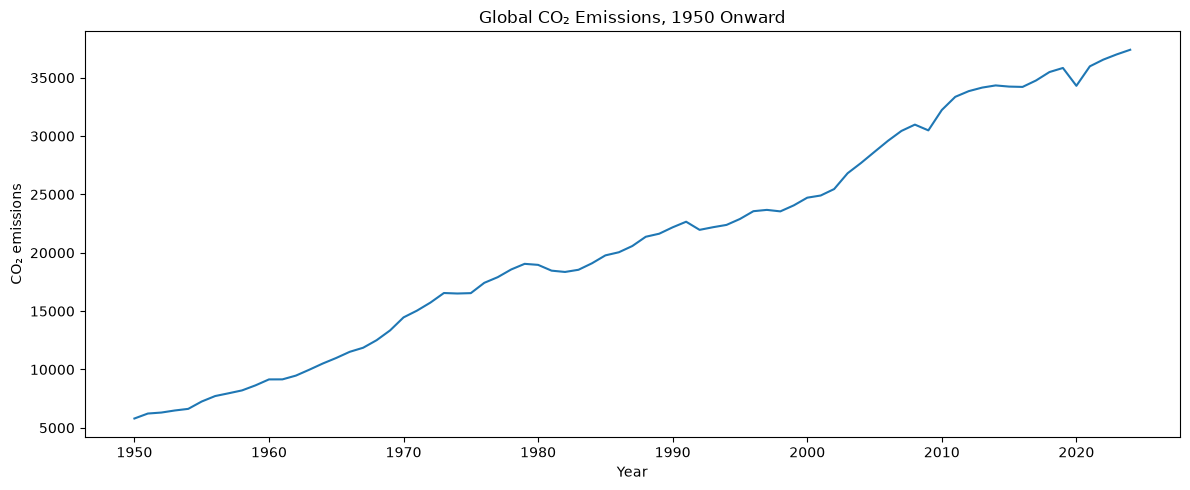

In [8]:
# Global annual CO2 trend
global_co2 = df.groupby("year", as_index=False)["co2"].sum()

plt.figure(figsize=(12, 5))
plt.plot(global_co2["year"], global_co2["co2"])
plt.title("Global CO₂ Emissions, 1950 Onward")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.tight_layout()
plt.show()

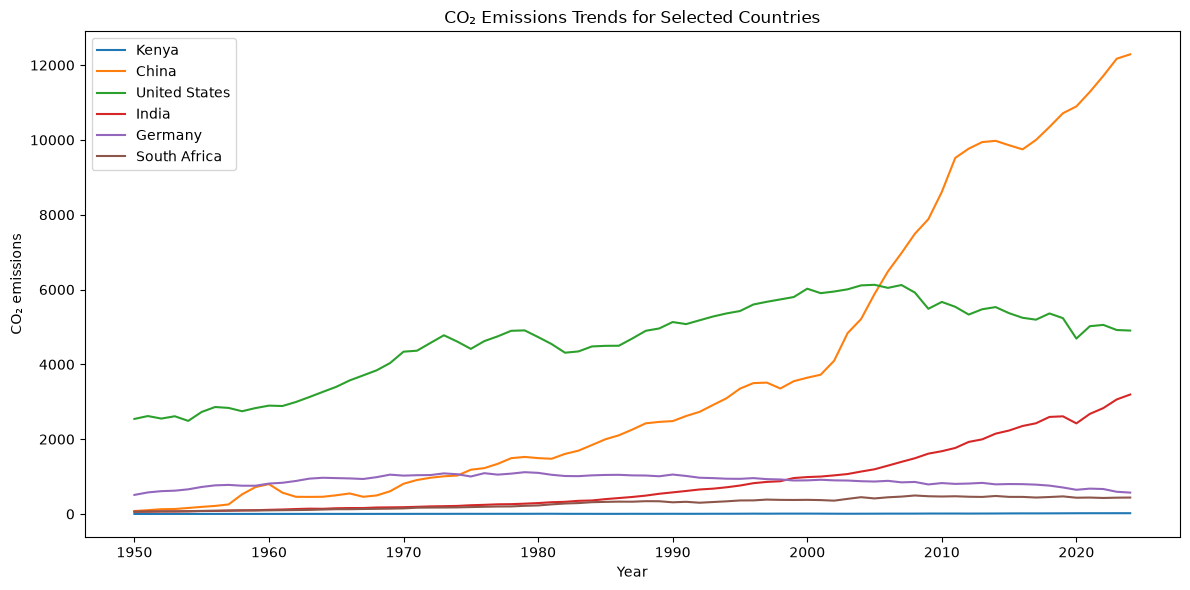

In [9]:
# Example country trends
selected_countries = ["Kenya", "China", "United States", "India", "Germany", "South Africa"]

plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = df[df["country"] == country]
    if not temp.empty:
        plt.plot(temp["year"], temp["co2"], label=country)

plt.title("CO₂ Emissions Trends for Selected Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Missing-Value Analysis

### Why?

Missing values must be handled based on the meaning of the variable. A missing CO₂ value does **not** automatically mean zero emissions.

For predictor variables:
- variables with excessive missingness may be removed;
- country-level numerical variables may be interpolated through time when appropriate;
- remaining missing values can be imputed inside the modelling pipeline.

For the target:
- missing `co2` values should **not** be imputed for supervised training;
- observations with missing target values are removed.

This prevents fabricated target values from becoming training labels.

In [10]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_percent")
)

display(missing.head(30))

,missing_percent
share_global_other_co2,90.152905
share_global_cumulative_other_co2,90.152905
other_industry_co2,89.675841
cumulative_other_co2,89.675841
other_co2_per_capita,89.675841
consumption_co2_per_gdp,76.091743
trade_co2_share,75.149847
trade_co2,75.149847
consumption_co2_per_capita,75.143731
consumption_co2,75.143731


## 9. Feature Selection

### Recommended variables

The first model uses:

**Identifiers/time**
- `iso_code`
- `country`
- `year`

**Target**
- `co2`

**Predictors**
- `population`
- `gdp`
- `primary_energy_consumption`
- `energy_per_capita`
- `energy_per_gdp`

### Why these variables?

Population and GDP represent demographic and economic activity. Energy variables represent the amount and efficiency of energy use. These relationships are supported by the IPCC literature.

### Variables to avoid initially

Avoid using current-year variables that are directly derived from `co2`, such as:
- `co2_per_capita`
- `co2_per_gdp`
- `co2_growth_abs`
- `co2_growth_prct`

Also avoid global-share and cumulative CO₂ variables in the first model.

Fuel-specific CO₂ variables such as `coal_co2`, `oil_co2` and `gas_co2` can be tested later as **lagged predictors**, but using their current-year values risks making the prediction artificially easy because they contribute directly to total CO₂.

In [11]:
base_features = [
    "population",
    "gdp",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp"
]

target = "co2"

available_features = [c for c in base_features if c in df.columns]

print("Available predictors:")
print(available_features)

print("\nMissingness of selected predictors:")
display(
    df[available_features + [target]]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percent")
)

Available predictors:
['population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp']

Missingness of selected predictors:


,missing_percent
energy_per_gdp,52.452599
energy_per_capita,39.669725
primary_energy_consumption,39.394495
gdp,29.926606
co2,6.605505
population,0.917431


## 10. Remove Features With Excessive Missingness

### Why?

A predictor with very high missingness may provide little reliable information and can require excessive imputation.

A 60% threshold is used here as an initial screening rule. This is not a universal rule; it should be reviewed alongside domain importance and model performance.

In [12]:
missing_threshold = 60

usable_features = [
    col for col in available_features
    if df[col].isna().mean() * 100 <= missing_threshold
]

print("Features retained after missingness screening:")
print(usable_features)

Features retained after missingness screening:
['population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp']


## 11. Handle Missing Values by Country and Time

### Why interpolate?

For annual country-level socioeconomic and energy indicators, interpolation can be reasonable when a small number of values are missing between known observations.

Interpolation is performed **within each ISO code**, so information from one country is never used to fill another country's values.

Important: for a strict forecasting pipeline, preprocessing should ideally be fitted only on training data. The exploratory cleaning below is therefore followed by a leakage-safe modelling pipeline.

In [13]:
# Work on a modelling copy
model_df = df[["country", "iso_code", "year", "co2"] + usable_features].copy()

# Do not impute the target
model_df = model_df.dropna(subset=["co2"])

# Interpolate predictors within each country
for col in usable_features:
    model_df[col] = (
        model_df.groupby("iso_code")[col]
        .transform(lambda x: x.interpolate(limit_direction="both"))
    )

print("Remaining missing values:")
display(model_df.isna().sum().sort_values(ascending=False))

Remaining missing values:


gdp                           3190
energy_per_gdp                3190
energy_per_capita              582
primary_energy_consumption     544
population                      83
country                          0
iso_code                         0
year                             0
co2                              0
dtype: int64

## 12. Create Time-Series Features

### Why create lags?

The strongest information about next year's emissions is often contained in the country's recent emissions history.

For example:
- `co2_lag_1` = previous year's CO₂;
- `co2_lag_2` = CO₂ two years earlier;
- `co2_lag_3` = CO₂ three years earlier;
- `co2_lag_5` = CO₂ five years earlier.

The same idea can be applied to GDP, population and energy.

This converts the problem into a supervised forecasting problem while preserving temporal order.

In [14]:
model_df = model_df.sort_values(["iso_code", "year"]).reset_index(drop=True)

# CO2 lags
for lag in [1, 2, 3, 5]:
    model_df[f"co2_lag_{lag}"] = (
        model_df.groupby("iso_code")["co2"].shift(lag)
    )

# One-year lags for predictor variables
for col in usable_features:
    model_df[f"{col}_lag_1"] = (
        model_df.groupby("iso_code")[col].shift(1)
    )

# Rolling average based only on previous years
model_df["co2_rolling_3"] = (
    model_df.groupby("iso_code")["co2_lag_1"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

display(model_df.head())

,country,iso_code,year,co2,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,co2_lag_1,co2_lag_2,co2_lag_3,co2_lag_5,population_lag_1,gdp_lag_1,primary_energy_consumption_lag_1,energy_per_capita_lag_1,energy_per_gdp_lag_1,co2_rolling_3
0,Aruba,ABW,1950,0.410,42763.0,NaN,0.426,6695.265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,1951,0.646,43880.0,NaN,0.426,6695.265,NaN,0.410,NaN,NaN,NaN,42763.0,NaN,0.426,6695.265,NaN,0.410000
2,Aruba,ABW,1952,0.373,45052.0,NaN,0.426,6695.265,NaN,0.646,0.410,NaN,NaN,43880.0,NaN,0.426,6695.265,NaN,0.528000
3,Aruba,ABW,1953,0.432,46269.0,NaN,0.426,6695.265,NaN,0.373,0.646,0.410,NaN,45052.0,NaN,0.426,6695.265,NaN,0.476333
4,Aruba,ABW,1954,0.873,47516.0,NaN,0.426,6695.265,NaN,0.432,0.373,0.646,NaN,46269.0,NaN,0.426,6695.265,NaN,0.483667


## 13. Define the Forecasting Target

### Why predict the next year?

The business problem is forecasting future emissions. A one-year-ahead target is a clear starting point and is easier to validate than an unrestricted long-term forecast.

`co2_next_year` is created using `shift(-1)` within each country. Therefore, information from year *t* is used to predict emissions in year *t+1*.

In [15]:
model_df["co2_next_year"] = (
    model_df.groupby("iso_code")["co2"].shift(-1)
)

print("Rows before target cleanup:", len(model_df))
model_df = model_df.dropna(subset=["co2_next_year"])

print("Rows after target cleanup:", len(model_df))

Rows before target cleanup: 15270
Rows after target cleanup: 15055


## 14. Final Modelling Features

The model uses historical information rather than current target-derived information.

### Why?

This prevents target leakage. At prediction time, the model should only receive information that would have been available before the future CO₂ value being predicted.

In [16]:
lag_features = (
    ["co2_lag_1", "co2_lag_2", "co2_lag_3", "co2_lag_5",
     "co2_rolling_3"]
    + [f"{col}_lag_1" for col in usable_features]
)

feature_columns = lag_features

print("Final model features:")
for feature in feature_columns:
    print("-", feature)

Final model features:
- co2_lag_1
- co2_lag_2
- co2_lag_3
- co2_lag_5
- co2_rolling_3
- population_lag_1
- gdp_lag_1
- primary_energy_consumption_lag_1
- energy_per_capita_lag_1
- energy_per_gdp_lag_1


## 15. Remove Rows That Cannot Support the Lagged Model

### Why?

The first few years of each country's time series do not have enough historical observations to calculate all lag features.

Those rows cannot be used for this specific model and are removed.

In [17]:
model_df = model_df.dropna(subset=feature_columns).copy()

print("Final modelling shape:", model_df.shape)
display(model_df[["country", "iso_code", "year"] + feature_columns + ["co2_next_year"]].head())

Final modelling shape: (11096, 20)


,country,iso_code,year,co2_lag_1,co2_lag_2,co2_lag_3,co2_lag_5,co2_rolling_3,population_lag_1,gdp_lag_1,primary_energy_consumption_lag_1,energy_per_capita_lag_1,energy_per_gdp_lag_1,co2_next_year
80,Afghanistan,AFG,1955,0.106,0.106,0.092,0.084,0.101333,8207954.0,1.086636e+10,6.337,481.209,0.413,0.183
81,Afghanistan,AFG,1956,0.154,0.106,0.106,0.092,0.122000,8326981.0,1.107819e+10,6.337,481.209,0.413,0.293
82,Afghanistan,AFG,1957,0.183,0.154,0.106,0.092,0.147667,8454303.0,1.158124e+10,6.337,481.209,0.413,0.330
83,Afghanistan,AFG,1958,0.293,0.183,0.154,0.106,0.210000,8588340.0,1.157897e+10,6.337,481.209,0.413,0.385
84,Afghanistan,AFG,1959,0.330,0.293,0.183,0.106,0.268667,8723412.0,1.223884e+10,6.337,481.209,0.413,0.414


# 16. CRISP-DM — Modelling

## Chronological Train / Validation / Test Split

### Why not `train_test_split()`?

Random splitting is inappropriate for forecasting because it can place future observations in the training set while older observations appear in the test set.

Instead:
- **Training:** earlier historical years
- **Validation:** later years
- **Testing:** the most recent years

This simulates the real business situation: learn from the past and predict the future.

In [18]:
# Use fixed chronological cutoffs.
# Adjust these after checking the final year range.
train_end = 2018
validation_end = 2021

train = model_df[model_df["year"] <= train_end].copy()
validation = model_df[
    (model_df["year"] > train_end) &
    (model_df["year"] <= validation_end)
].copy()
test = model_df[model_df["year"] > validation_end].copy()

print("Train:", train["year"].min(), "to", train["year"].max(), len(train))
print("Validation:", validation["year"].min(), "to", validation["year"].max(), len(validation))
print("Test:", test["year"].min(), "to", test["year"].max(), len(test))

Train: 1955 to 2018 10276
Validation: 2019 to 2021 492
Test: 2022 to 2023 328


## 17. Prepare X and y

### Why?

`X` contains the predictors and `y` contains the future CO₂ value that the model must learn to predict.

In [19]:
X_train = train[feature_columns]
y_train = train["co2_next_year"]

X_val = validation[feature_columns]
y_val = validation["co2_next_year"]

X_test = test[feature_columns]
y_test = test["co2_next_year"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (10276, 10)
X_test: (328, 10)


## 18. Baseline Model — Persistence Forecast

### Why?

A baseline tells us whether machine learning is actually adding value.

The persistence assumption is:

> Next year's CO₂ = this year's CO₂.

A sophisticated model should beat this simple benchmark. Otherwise, the additional complexity is not justified.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_pred = test["co2"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Persistence Baseline")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Persistence Baseline
MAE : 7.028070121951218
RMSE: 32.38273497875474
R²  : 0.9990664454115632


## 19. Linear Regression

### Why?

Linear Regression provides an interpretable benchmark. It tests whether a mostly linear relationship between historical emissions, population, GDP and energy variables is sufficient for forecasting.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R²  :", r2_score(y_test, linear_pred))

Linear Regression
MAE : 10.911937408165747
RMSE: 33.18897630324079
R²  : 0.9990193808259604


## 20. Random Forest Regressor

### Why?

Random Forest can capture nonlinear relationships and interactions between economic, population, energy and historical emissions features.

It is also useful for interpretation through feature importance.

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²  :", r2_score(y_test, rf_pred))

Random Forest
MAE : 27.297864085365823
RMSE: 156.58913412891076
R²  : 0.9781708958978412


## 21. XGBoost — Optional

### Why?

Gradient-boosted trees can capture complex nonlinear patterns and may improve accuracy on structured tabular data.

This cell is optional because XGBoost may not be installed in every environment.

In [23]:
# Uncomment and run if XGBoost is installed:
#
# from xgboost import XGBRegressor
#
# xgb_model = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("model", XGBRegressor(
#         n_estimators=300,
#         learning_rate=0.05,
#         max_depth=5,
#         random_state=42,
#         objective="reg:squarederror"
#     ))
# ])
#
# xgb_model.fit(X_train, y_train)
# xgb_pred = xgb_model.predict(X_test)
#
# print("XGBoost")
# print("MAE :", mean_absolute_error(y_test, xgb_pred))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
# print("R²  :", r2_score(y_test, xgb_pred))

# 22. CRISP-DM — Evaluation

### Why use multiple metrics?

CO₂ emissions differ enormously between countries. MAE and RMSE measure error in the original emissions units, while R² provides a relative measure of explained variation.

For this project:
- **MAE** is the primary easy-to-interpret error measure.
- **RMSE** penalises very large errors.
- **R²** is used as a supporting metric.
- MAPE is not recommended as the only metric because very small emissions can make percentage errors unstable.

In [24]:
results = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        baseline_rmse,
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2": [
        baseline_r2,
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ]
})

display(results.sort_values("RMSE"))

,Model,MAE,RMSE,R2
0,Persistence Baseline,7.028070,32.382735,0.999066
1,Linear Regression,10.911937,33.188976,0.999019
2,Random Forest,27.297864,156.589134,0.978171


## 23. Actual vs Predicted CO₂

### Why?

A numerical metric tells us how large the error is, but a plot helps reveal systematic underprediction, overprediction and unusual observations.

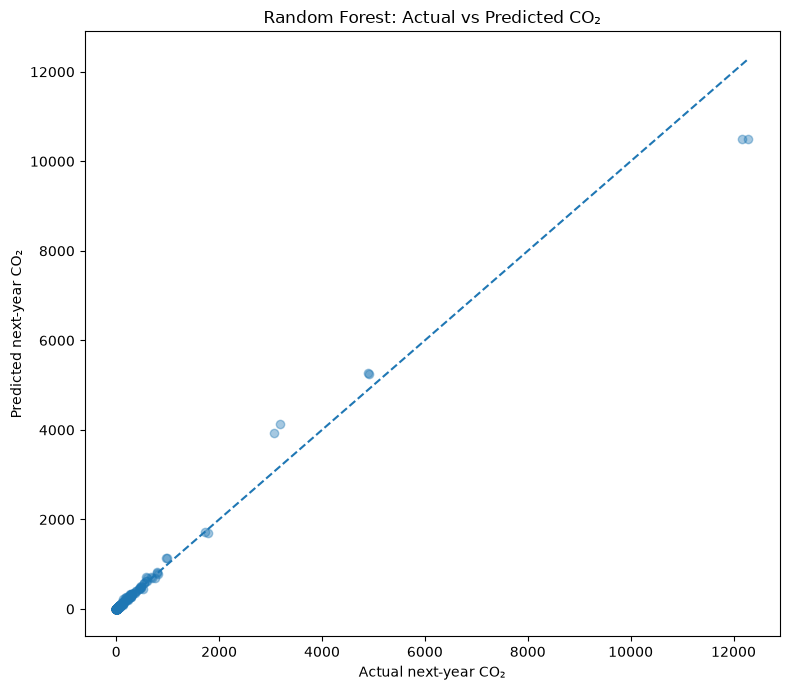

In [25]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, rf_pred, alpha=0.4)

lims = [
    min(y_test.min(), rf_pred.min()),
    max(y_test.max(), rf_pred.max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual next-year CO₂")
plt.ylabel("Predicted next-year CO₂")
plt.title("Random Forest: Actual vs Predicted CO₂")
plt.tight_layout()
plt.show()

## 24. Feature Importance

### Why?

Feature importance helps answer one of the business questions:

> Which historical factors are most useful for predicting future CO₂ emissions?

A strong forecasting model should not only be accurate; its important predictors should also make domain sense.

,importance
co2_rolling_3,0.245032
co2_lag_1,0.242720
co2_lag_2,0.172260
co2_lag_3,0.161299
co2_lag_5,0.086680
primary_energy_consumption_lag_1,0.050604
population_lag_1,0.025082
gdp_lag_1,0.013735
energy_per_gdp_lag_1,0.001660
energy_per_capita_lag_1,0.000927


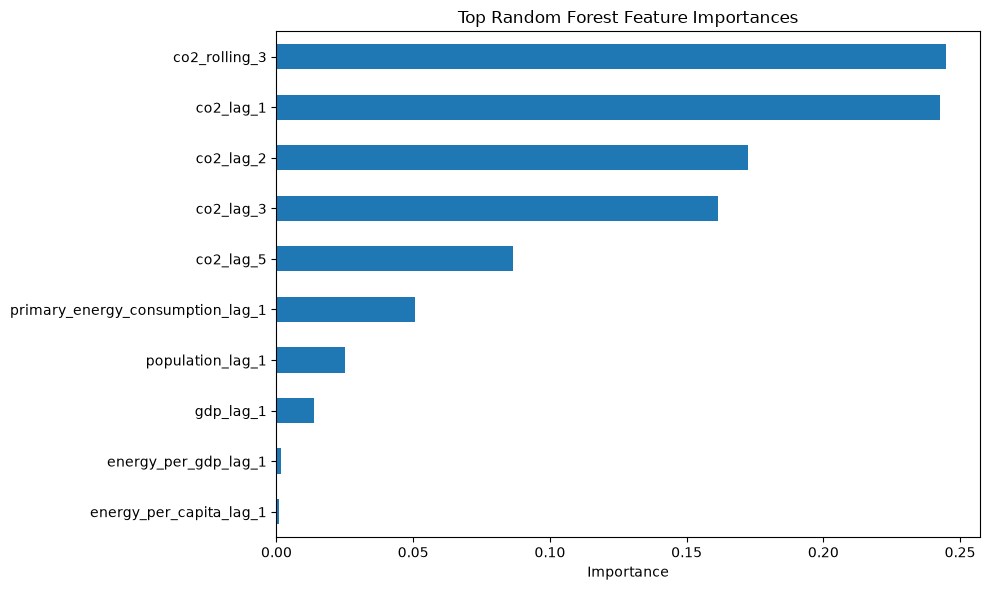

In [26]:
rf_estimator = rf_model.named_steps["model"]

importance = pd.Series(
    rf_estimator.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

display(importance.to_frame("importance"))

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 25. Country-Level Evaluation

### Why?

Overall accuracy can hide poor performance for particular countries. A model may perform very well on large emitters while producing relatively weak forecasts for smaller countries.

Therefore, calculate errors by country and identify where the model performs best and worst.

In [27]:
evaluation = test[["country", "iso_code", "year", "co2_next_year"]].copy()
evaluation["prediction"] = rf_pred
evaluation["absolute_error"] = (
    evaluation["co2_next_year"] - evaluation["prediction"]
).abs()

country_results = (
    evaluation.groupby(["country", "iso_code"])
    .agg(
        MAE=("absolute_error", "mean"),
        observations=("absolute_error", "size")
    )
    .sort_values("MAE")
)

display(country_results.head(15))
display(country_results.tail(15))

,,MAE,observations
country,iso_code,,
Dominica,DMA,0.002578,2
Sao Tome and Principe,STP,0.012047,2
Comoros,COM,0.035138,2
Gambia,GMB,0.035927,2
Burundi,BDI,0.044795,2
Djibouti,DJI,0.049795,2
Central African Republic,CAF,0.052878,2
Guinea-Bissau,GNB,0.053552,2
Liberia,LBR,0.055223,2


,,MAE,observations
country,iso_code,,
Canada,CAN,35.119435,2
South Korea,KOR,39.952798,2
Turkey,TUR,40.320435,2
Spain,ESP,43.153708,2
France,FRA,44.657963,2
Russia,RUS,46.930233,2
Poland,POL,53.310460,2
Ukraine,UKR,54.109977,2
Indonesia,IDN,57.335770,2


# 26. Forecasting Future Years

### Why?

After evaluating the model on historical holdout data, the final model can be retrained using all available historical observations and used to generate future one-step-ahead forecasts.

For a production forecasting system, future economic and energy assumptions would also need to be available. If only historical emissions are available, a simpler autoregressive model is preferable.

This notebook therefore treats future forecasting as the final deployment stage after model evaluation.

In [28]:
# Example: latest available observations for each country
latest = (
    model_df.sort_values(["iso_code", "year"])
    .groupby("iso_code")
    .tail(1)
)

print("Latest modelling year:", latest["year"].max())
display(
    latest[["country", "iso_code", "year", "co2"]]
    .sort_values("co2", ascending=False)
    .head(20)
)

Latest modelling year: 2023


,country,iso_code,year,co2
2680,China,CHN,2023,12172.009
14432,United States,USA,2023,4918.407
6360,India,IND,2023,3062.756
11604,Russia,RUS,2023,1733.135
7035,Japan,JPN,2023,986.910
6510,Iran,IRN,2023,789.676
6285,Indonesia,IDN,2023,762.358
11754,Saudi Arabia,SAU,2023,677.442
3747,Germany,DEU,2023,593.766
7544,South Korea,KOR,2023,589.178


# 27. CRISP-DM — Deployment

The completed system can support a recurring emissions-monitoring workflow:

1. Load the latest OWID data.
2. Apply the same cleaning rules.
3. Generate country-level lag features.
4. Retrain or update the selected model.
5. Forecast the next year's CO₂ emissions.
6. Compare forecasts with actual emissions when they become available.
7. Monitor model performance by country.

### Business outputs

The final deliverable should include:
- predicted CO₂ emissions by country;
- expected direction of change;
- model accuracy;
- country-level error;
- important predictors;
- charts showing historical and predicted trends.

The model should be treated as a forecasting aid rather than a guarantee of future emissions because policy, technology, economic shocks, wars, energy-price changes and other external events can change emissions trajectories.

# 28. Final Conclusions Template

After running the notebook, complete the following conclusions using the actual model results:

### Data preparation
The dataset was restricted to observations from 1950 onward, country observations without ISO codes were removed, duplicate country-year records were handled, missing target values were excluded, and predictor missingness was addressed using country-level interpolation and modelling-pipeline imputation.

### Feature engineering
Lagged CO₂, lagged socioeconomic and energy variables, and a three-year rolling CO₂ average were created to represent historical information available before the forecast year.

### Modelling
A persistence baseline, Linear Regression and Random Forest were compared. XGBoost can be added as an optional boosted-tree model.

### Evaluation
The preferred model should be selected based primarily on **MAE and RMSE**, while ensuring that it outperforms the persistence baseline and performs reasonably across countries.

### Business interpretation
The final analysis should identify the most important historical predictors and highlight countries whose emissions trajectories are increasing, stable or decreasing.

### Final research question
**How accurately can historical country-level CO₂ emissions, population, GDP and energy characteristics be used to forecast future CO₂ emissions?**

# 29. References

1. **IPCC (2022).** *Climate Change 2022: Mitigation of Climate Change — Working Group III, Chapter 2: Emissions Trends and Drivers.*  
   https://www.ipcc.ch/report/ar6/wg3/downloads/report/IPCC_AR6_WGIII_Chapter02.pdf

2. **Costantini et al. (2024).** *Global CO₂ emissions forecasting based on socioeconomic and energy-related indicators.* Scientific Reports.  
   https://www.nature.com/articles/s41598-024-73060-0

3. **Our World in Data.** CO₂ and Greenhouse Gas Emissions Dataset.  
   https://ourworldindata.org/co2-emissions